In [1]:
import os
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from collections import Counter

In [3]:
PROJECT_ROOT = Path("..")
DATASET_DIR = PROJECT_ROOT/"datasets"/"raw"/"astro_dataset_maxia"

TRAIN_DIR = DATASET_DIR/"training"
TEST_DIR = DATASET_DIR/"test"
VAL_DIR = DATASET_DIR/"validation"

print(TRAIN_DIR)
print(TEST_DIR)
print(VAL_DIR)

..\datasets\raw\astro_dataset_maxia\training
..\datasets\raw\astro_dataset_maxia\test
..\datasets\raw\astro_dataset_maxia\validation


In [4]:
classes = sorted(
    [
        folder.name
        for folder in TRAIN_DIR.iterdir()
        if folder.is_dir()
    ]
)
print(f"Number of classes: {len(classes)}")
print("Classes Found:")
print(classes)

Number of classes: 12
Classes Found:
['asteroid', 'black_hole', 'earth', 'galaxy', 'jupiter', 'mars', 'mercury', 'neptune', 'pluto', 'saturn', 'uranus', 'venus']


In [6]:
splits = {
    "Traininig": TRAIN_DIR,
    "Validation": VAL_DIR,
    "Test": TEST_DIR
}

for split_name, split_path in splits.items():
    print(f"\n{split_name}")
    total = 0
    for cls in classes:
        count = len(list((split_path/cls).glob("*")))
        total += count
        print(f"{cls:<15} {count}")
        
    print("-" * 30)
    print(f"Total Images: {total}")


Traininig
asteroid        212
black_hole      185
earth           209
galaxy          185
jupiter         202
mars            215
mercury         201
neptune         202
pluto           201
saturn          201
uranus          202
venus           201
------------------------------
Total Images: 2416

Validation
asteroid        42
black_hole      48
earth           59
galaxy          49
jupiter         57
mars            61
mercury         57
neptune         57
pluto           57
saturn          57
uranus          57
venus           57
------------------------------
Total Images: 658

Test
asteroid        29
black_hole      31
earth           29
galaxy          30
jupiter         28
mars            30
mercury         28
neptune         28
pluto           28
saturn          28
uranus          28
venus           28
------------------------------
Total Images: 345


In [7]:
summary = []

for cls in classes:
    train_count = len(list((TRAIN_DIR/cls).glob("*")))
    val_count = len(list((VAL_DIR/cls).glob("*")))
    test_count = len(list((TEST_DIR/cls).glob("*")))
    
    summary.append({
        "Class": cls,
        "Train": train_count,
        "Validation": val_count,
        "Test": test_count,
        "Total": train_count + val_count + test_count
        
    })
    
    df = pd.DataFrame(summary)
    df

In [8]:
print(f"Number of Classes : {len(classes)}")
print(f"Training Images : {df['Train'].sum()}")
print(f"Validation Images : {df['Validation'].sum()}")
print(f"Testing Images : {df['Test'].sum()}")
print(f"Total Images : {df['Total'].sum()}")

Number of Classes : 12
Training Images : 2416
Validation Images : 658
Testing Images : 345
Total Images : 3419


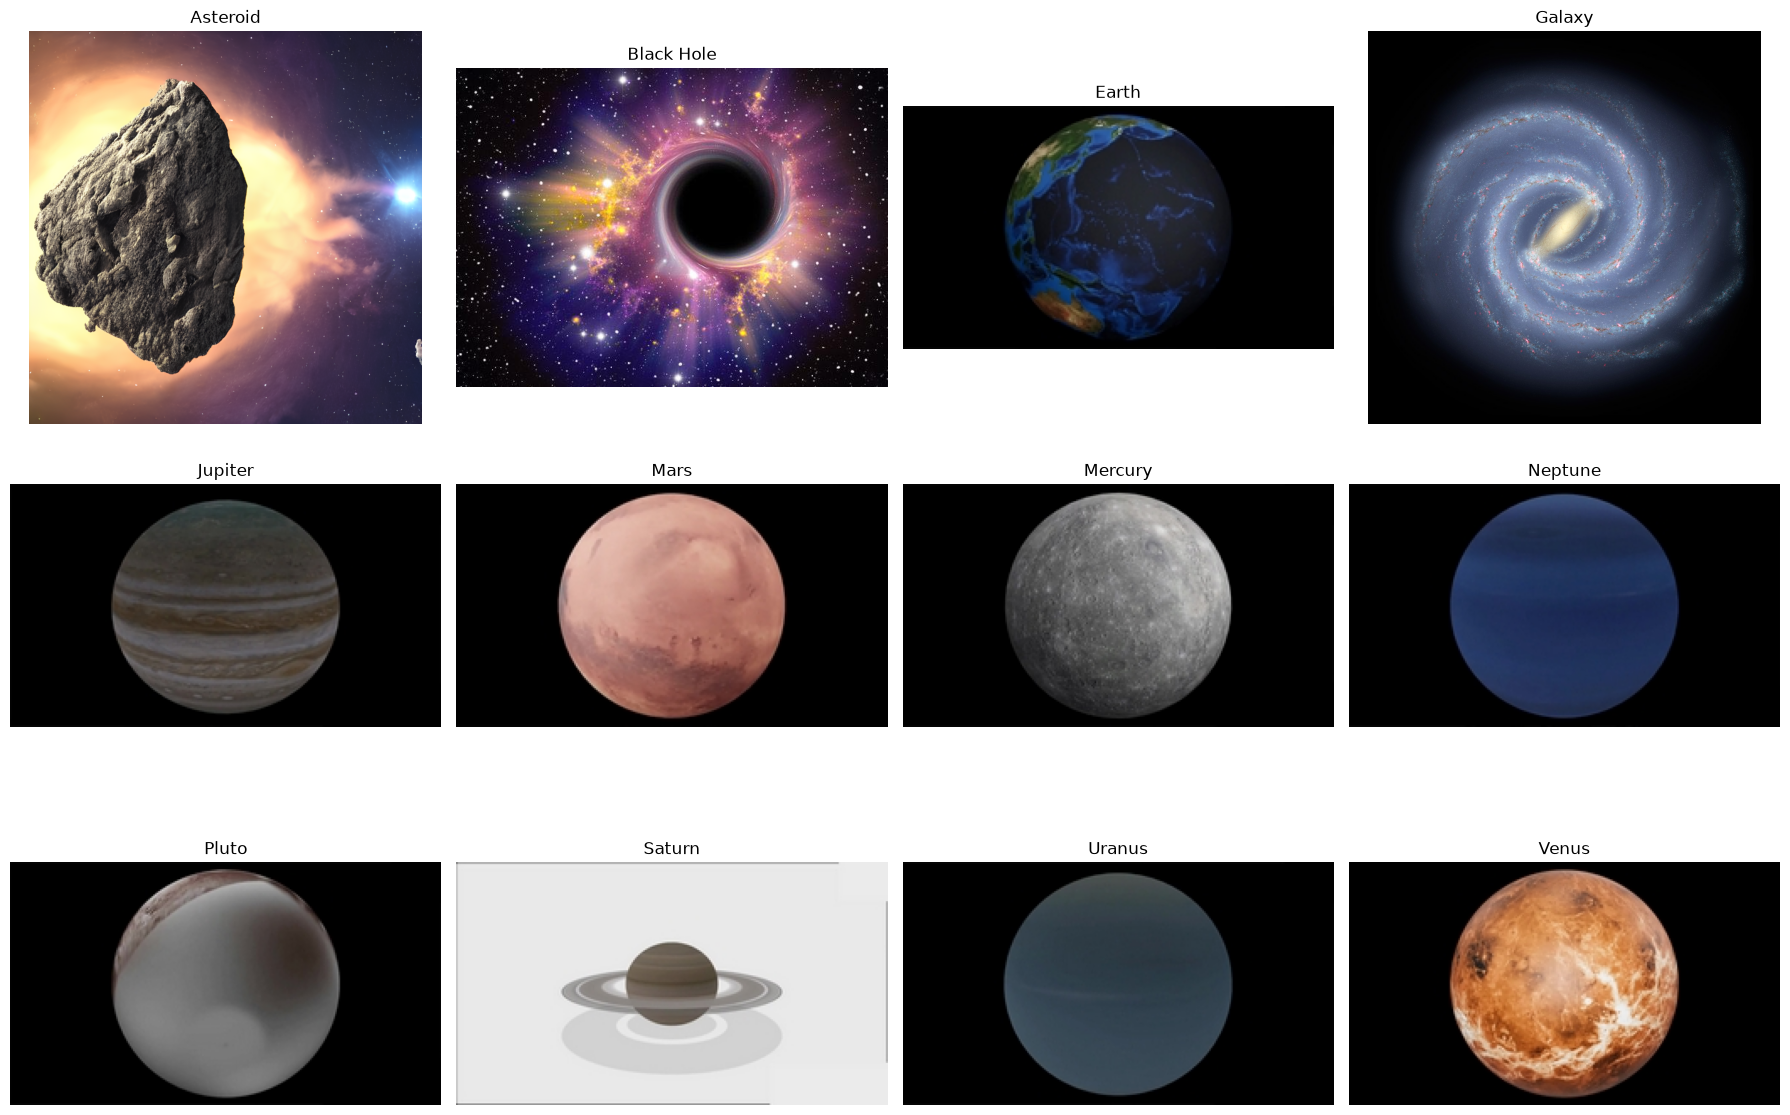

In [9]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))

axes = axes.flatten()

for i, cls in enumerate(classes):
    image_path = next((TRAIN_DIR / cls).glob("*"))
    img = Image.open(image_path)

    axes[i].imshow(img)
    axes[i].set_title(cls.replace("_", " ").title())
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [10]:
sample = next((TRAIN_DIR/classes[0]).glob("*"))
print(sample)
img = Image.open(sample)
print(img.size)

..\datasets\raw\astro_dataset_maxia\training\asteroid\asteroid_page_1_image_10_0_SwinIR_large.png
(2048, 2048)


In [11]:
print(TRAIN_DIR)

..\datasets\raw\astro_dataset_maxia\training


In [12]:
# image resolution analysis
resolution_counter = Counter()

for split_path in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    for cls in classes:
        for image_path in (split_path/cls).glob("*"):
            
            try: 
                with Image.open(image_path) as img:
                    resolution_counter[img.size] += 1
                      
            except Exception:
                pass
            
print(f"Unique Image Resolutions:{len(resolution_counter)}")
resolution_df = (
    pd.DataFrame(
        resolution_counter.items(),
        columns=["Resolution", "Count"]
    )
    .sort_values(by="Count", ascending = False)
)

resolution_df.head(10)

Unique Image Resolutions:441


,Resolution,Count
123,"(256, 144)",1923
0,"(2048, 2048)",283
134,"(462, 260)",124
127,"(260, 260)",63
137,"(390, 260)",46
28,"(1200, 675)",45
131,"(347, 260)",31
33,"(1024, 1024)",28
309,"(463, 260)",27
381,"(1020, 1020)",25


In [13]:
# image format analysis
format_counter = Counter()

for split_path in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
     for cls in classes:
         for image_path in (split_path/cls).glob("*"):
            try:
                 with Image.open(image_path) as img:
                     format_counter[img.format] += 1
            except:
                pass
format_counter

Counter({'JPEG': 3104, 'PNG': 306, 'WEBP': 9})

In [14]:
# check for corrupted images
corrupted = []

for split_path in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    for cls in classes:
        for image_path in(split_path/cls).glob("*"):
            try:
                with Image.open(image_path) as img:
                    img.verify()
            except Exception:
                corrupted.append(image_path)
print(f"Corrupted Images: {len(corrupted)}")
corrupted[:10]

Corrupted Images: 0


[]

In [15]:
# dataset summary
dataset_summary = {
    "Classes": len(classes),
    "Training Images": df["Train"].sum(),
    "Validation Images": df["Validation"].sum(),
    "Testing Images": df["Test"].sum(),
    "Total Images": df["Total"].sum(),
    "Corrupted Images": len(corrupted)
}

for key, value in dataset_summary.items():
    print(f"{key:<20}: {value}")

Classes             : 12
Training Images     : 2416
Validation Images   : 658
Testing Images      : 345
Total Images        : 3419
Corrupted Images    : 0


# Conclusion

## Objective
To inspect the astronomy image dataset and verify its structure, class distribution, and overall suitability for training a deep learning model.

## What We Did
- Explored the dataset directory structure.
- Identified all available image classes.
- Counted the number of images in each class.
- Checked for missing or inconsistent folders.
- Verified train, validation, and test splits.

## Results
- Successfully identified 12 astronomy classes.
- Verified that the dataset was properly organized.
- Confirmed that the dataset was suitable for image classification.

## Key Learnings
- Understanding dataset organization.
- Importance of balanced datasets.
- Train, validation, and test split verification.
- Data quality assessment.

## Conclusion
The dataset audit confirmed that the astronomy dataset was well-structured and ready for preprocessing and model development.